# AFM Diagram

The AFM diagram is a ternary diagram commonly used to visualize igneous rock compositions using:

- `A = Na2O + K2O`;
- `F = FeOT`;
- `M = MgO`.

This notebook shows both the high-level `AFM()` function and the low-level ternary plotting tools used to build custom figures.

## Import Libraries and Load the Dataset

The AFM plotting tools are available from `geochem.plt`. The example dataset is loaded and preprocessed before plotting.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geochem.plt as gc
from geochem.parameters import getvalues_IB71

In [2]:
DOCS_DIR = Path.cwd()
if not (DOCS_DIR / "data_example.csv").exists():
    DOCS_DIR = Path.cwd() / "docs"

csv_file = DOCS_DIR / "data_example.csv"
df = pd.read_csv(csv_file)

gc.preproc(df)
df.head()

Strip whitespaces from column names
>  column names before:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2 ', 'Al2O3 ', 'TiO2 ', 'FeO', 'Fe2O3 ', 'FeOT', 'CaO ', 'MgO', 'MnO ', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']
>  column names after:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2', 'Al2O3', 'TiO2', 'FeO', 'Fe2O3', 'FeOT', 'CaO', 'MgO', 'MnO', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']

Ensuring geochemical data columns are numeric
>  Processed/verified numeric columns: Cr (parsed)

Check columns with Fe oxides and calculate FeOT
.. FeO column in database
.. Fe2

,Sample,Type,Description,Reference,Source,SiO2,Al2O3,TiO2,FeO,Fe2O3,...,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu
0,HOR-06-01,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.55,17.42,0.81,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CLHE1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.35,17.76,0.83,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CLHE2,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.08,17.02,0.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CLHE-TF-04,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,51.51,13.99,0.64,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLHW1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.73,17.91,0.88,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Prepare AFM Components Manually

The high-level `AFM()` function can do this internally, but it is useful to see the components explicitly.

The major oxides are first normalized to 100 wt% using `closure()`.

In [3]:
major_oxides = gc.getnames_major()
df_major = df[major_oxides].copy()
df_major = gc.closure(df_major, total=100)

df_major["A"] = df_major["Na2O"] + df_major["K2O"]
df_major["F"] = df_major["FeOT"]
df_major["M"] = df_major["MgO"]
df_major["Source"] = df["Source"]

df_major[["A", "F", "M", "Source"]].head()

,A,F,M,Source
0,4.329355,7.566255,5.614000,Hornitos
1,4.363419,7.531381,5.469217,Hornitos
2,4.267383,7.629563,6.883517,Hornitos
3,3.015225,8.090357,13.593392,Hornitos
4,4.344793,7.483807,6.038864,Hornitos


## High-Level AFM Diagram

Use `AFM()` for a quick AFM diagram. By default, it draws the ternary frame, plots the Irvine and Baragar (1971) boundary, normalizes the major oxides, and removes rows with missing values.

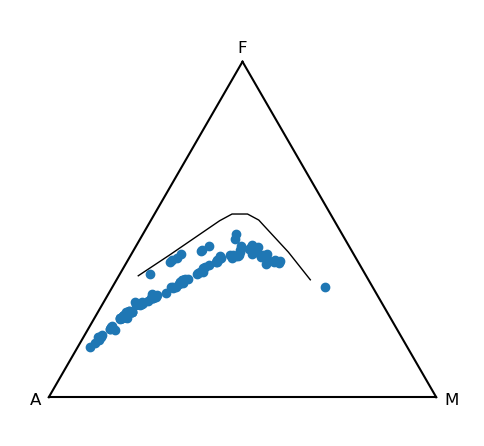

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
gc.AFM(df, fmt={"show": False}, ax=ax)
plt.show()

Use `fmt={"groupby": "Source"}` to color groups by a metadata column.

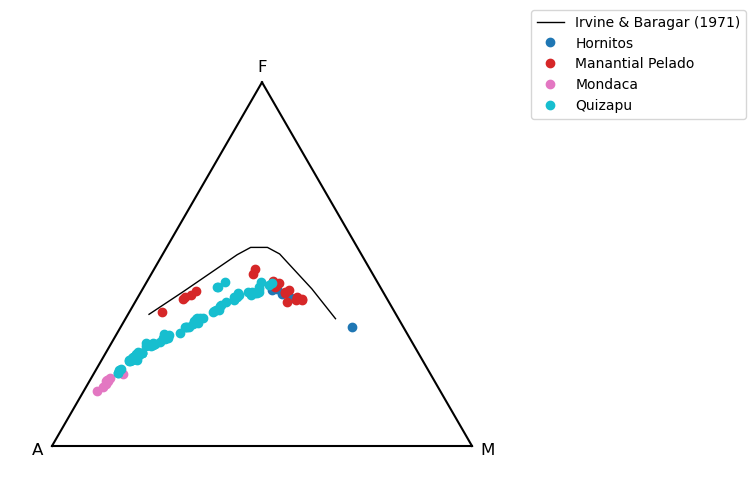

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
gc.AFM(df, fmt={"groupby": "Source", "show": False}, ax=ax)
plt.show()

## NumPy-Style Input

`AFM()` also accepts a sequence of three arrays: `[A, F, M]`.

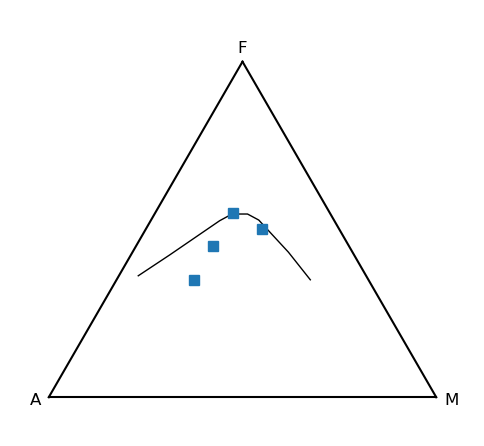

In [6]:
A = np.array([25.0, 35.0, 45.0, 20.0])
F = np.array([55.0, 45.0, 35.0, 50.0])
M = np.array([20.0, 20.0, 20.0, 30.0])

fig, ax = plt.subplots(figsize=(6, 6))
gc.AFM([A, F, M], fmt={"fmt_plt": {"marker": "s", "linestyle": "", "ms": 7}, "show": False}, ax=ax)
plt.show()

## Build an AFM Figure Step by Step

The low-level ternary tools are:

- `triangle()` to draw a ternary frame;
- `tridata()` to add ternary data;
- `convert_abc_to_xy()` to convert ternary coordinates to x-y coordinates;
- `triangle_lineplot()` to draw lines parallel to triangle sides.

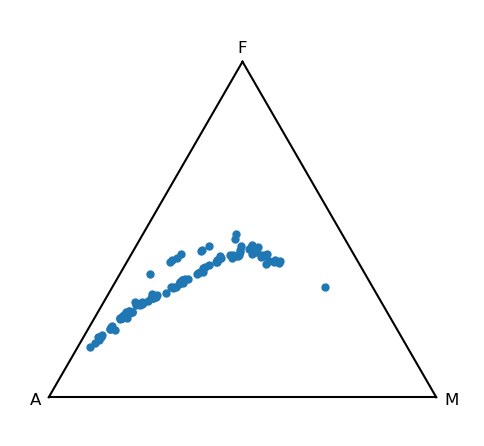

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
gc.triangle(fmt={"verts": ("A", "F", "M"), "show": False}, ax=ax)

gc.tridata(
    x=df_major["A"].to_numpy(),
    y=df_major["F"].to_numpy(),
    z=df_major["M"].to_numpy(),
    fmt={"fmt_plt": {"marker": "o", "linestyle": "", "ms": 5}, "show": False},
    ax=ax,
)

plt.show()

## Custom Grouped Ternary Plot

Manual plotting makes it easy to use custom symbols for each group.

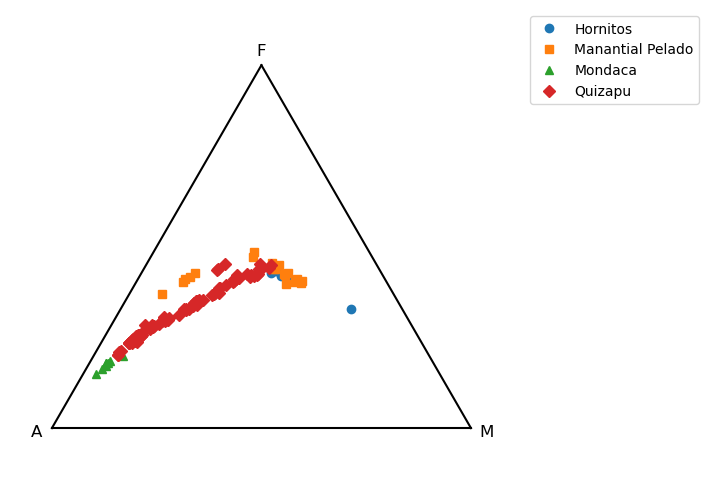

In [8]:
markers = {
    "Hornitos": "o",
    "Manantial Pelado": "s",
    "Mondaca": "^",
    "Quizapu": "D",
}

fig, ax = plt.subplots(figsize=(7, 6))
gc.triangle(fmt={"verts": ("A", "F", "M"), "show": False}, ax=ax)

for source, group in df_major.dropna(subset=["A", "F", "M"]).groupby("Source"):
    gc.tridata(
        x=group["A"].to_numpy(),
        y=group["F"].to_numpy(),
        z=group["M"].to_numpy(),
        fmt={
            "fmt_plt": {"marker": markers.get(source, "o"), "linestyle": "", "ms": 6},
            "label": source,
            "show": False,
        },
        ax=ax,
    )

ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
fig.tight_layout()
plt.show()

## Add the Irvine and Baragar Boundary Manually

The AFM reference boundary is available through `geochem.parameters.getvalues_IB71()` as ternary coordinates. It can be added with `tridata()`.

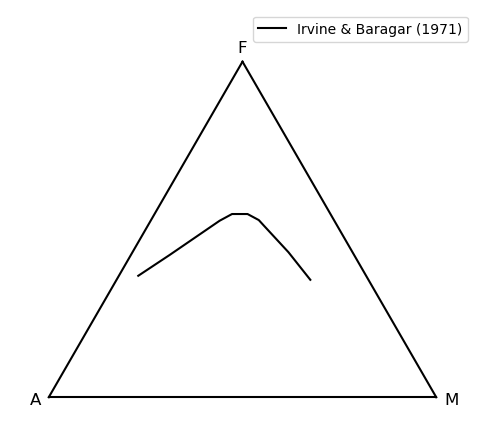

In [9]:
ib_A, ib_F, ib_M = getvalues_IB71()

fig, ax = plt.subplots(figsize=(6, 6))
gc.triangle(fmt={"verts": ("A", "F", "M"), "show": False}, ax=ax)

gc.tridata(
    x=ib_A,
    y=ib_F,
    z=ib_M,
    fmt={"fmt_plt": {"marker": "", "linestyle": "-", "color": "black"}, "label": "Irvine & Baragar (1971)", "show": False},
    ax=ax,
)

ax.legend()
plt.show()

## Lines Parallel to Triangle Sides

`triangle_lineplot()` can be used to draw construction lines in a ternary diagram.

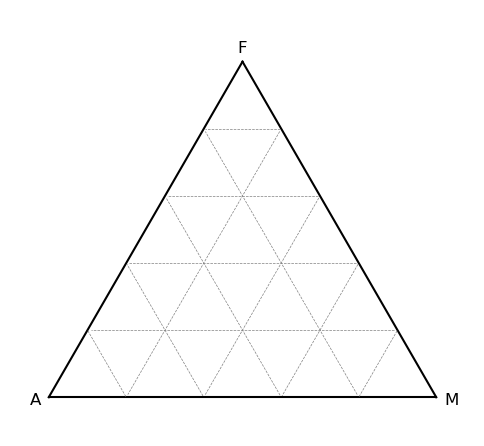

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
gc.triangle(fmt={"verts": ("A", "F", "M"), "show": False}, ax=ax)

line_fmt = {"fmt_plt": {"linestyle": "dashed", "linewidth": 0.5, "color": "gray"}, "show": False}
for component in [0, 1, 2]:
    gc.triangle_lineplot(icomp=component, perc=np.linspace(0.2, 0.8, 4), fmt=line_fmt, ax=ax)

plt.show()

## Summary

Use `gc.AFM(df)` for quick AFM diagrams. Use `triangle()`, `tridata()`, and `triangle_lineplot()` when building customized ternary figures or adding custom reference lines.